In [10]:
import pandas as pd
import numpy as np

# 1. NHẬP DỮ LIỆU TRỰC TIẾP TỪ BẢNG 3.3 (Trích từ tài liệu [1, 2])
data = {
    'Ngành': [
        "Nông-Lâm-Thủy sản", "CN chế biến chế tạo", "Xây dựng", "Khai khoáng",
        "Bán buôn-bán lẻ", "Tài chính-Ngân hàng", "Logistics-Vận tải",
        "CNTT-Truyền thông", "Giáo dục-Đào tạo", "Y tế"
    ],
    'Tăng trưởng (%)': [3.27, 9.64, 7.45, -1.20, 7.10, 7.36, 9.93, 7.85, 6.42, 6.85],
    'Năng suất (tr.VND/LĐ)': [103.4, 241.2, 168.8, 1290.5, 145.3, 1072.4, 321.4, 713.8, 205.7, 437.1],
    'Lan tỏa (0-1)': [0.35, 0.78, 0.42, 0.30, 0.55, 0.85, 0.72, 0.92, 0.65, 0.60],
    'XK (tỷ USD)': [40.5, 290.9, 2.5, 8.2, 5.5, 1.2, 3.1, 178.0, 0.0, 0.0],
    'Việc làm (tr.LĐ)': [13.20, 11.50, 4.80, 0.30, 7.80, 0.55, 1.95, 0.62, 2.15, 0.75],
    'AI Readiness (0-100)': [15, 55, 20, 30 , 48, 72, 42 , 88, 38, 45],
    'Rủi ro TĐH (%)': [18, 42, 25, 55, 38, 52, 35, 28, 22, 18]

}

df_raw = pd.DataFrame(data)



# 2. LỰA CHỌN CÁC CỘT ĐỂ CHUẨN HÓA (Theo yêu cầu Câu 3.4.1 [19-21])
cols_good = [
    'Tăng trưởng (%)', 'Năng suất (tr.VND/LĐ)', 'Lan tỏa (0-1)', 
    'XK (tỷ USD)', 'Việc làm (tr.LĐ)', 'AI Readiness (0-100)'
]
col_bad = 'Rủi ro TĐH (%)'

# 3. ĐỊNH NGHĨA HÀM CHUẨN HÓA MIN-MAX (Theo Mục 3.2 [1])
def norm_good(x): 
    return (x - x.min()) / (x.max() - x.min())

def norm_bad(x):  
    return (x.max() - x) / (x.max() - x.min())

# 4. THỰC HIỆN CHUẨN HÓA
df_normalized = df_raw[['Ngành']].copy() # Giữ lại cột tên ngành
X_good = df_raw[cols_good].apply(norm_good)
X_bad = norm_bad(df_raw[col_bad])

# Ghép các kết quả lại
df_final = pd.concat([df_normalized, X_good, X_bad], axis=1)

# 5. IN KẾT QUẢ MA TRẬN ĐÃ CHUẨN HÓA
print("--- MA TRẬN ĐÃ CHUẨN HÓA MIN-MAX (CÂU 3.4.1) ---")
print(df_final.round(4).to_string(index=False))

# In dạng mảng Numpy để phục vụ các bài sau nếu cần
print("\n--- MA TRẬN DƯỚI DẠNG ARRAY (NUMPY) ---")
# Loại bỏ cột 'Ngành' để lấy ma trận số thuần túy
matrix_values = df_final.drop(columns=['Ngành']).values
print(matrix_values)

--- MA TRẬN ĐÃ CHUẨN HÓA MIN-MAX (CÂU 3.4.1) ---
              Ngành  Tăng trưởng (%)  Năng suất (tr.VND/LĐ)  Lan tỏa (0-1)  XK (tỷ USD)  Việc làm (tr.LĐ)  AI Readiness (0-100)  Rủi ro TĐH (%)
  Nông-Lâm-Thủy sản           0.4016                 0.0000         0.0806       0.1392            1.0000                0.0000          1.0000
CN chế biến chế tạo           0.9739                 0.1161         0.7742       1.0000            0.8682                0.5479          0.3514
           Xây dựng           0.7772                 0.0551         0.1935       0.0086            0.3488                0.0685          0.8108
        Khai khoáng           0.0000                 1.0000         0.0000       0.0282            0.0000                0.2055          0.0000
    Bán buôn-bán lẻ           0.7457                 0.0353         0.4032       0.0189            0.5814                0.4521          0.4595
Tài chính-Ngân hàng           0.7691                 0.8163         0.8871       0.0041

In [11]:
# 1. Định nghĩa bộ trọng số mặc định (a1 đến a7) [1]
# Thứ tự: Tăng trưởng, Năng suất, Lan tỏa, Xuất khẩu, Việc làm, AI Readiness, Rủi ro TĐH (đã đảo dấu)
weights = np.array([0.15, 0.15, 0.20, 0.15, 0.10, 0.20, 0.15])

# 2. Tính chỉ số Priority cho từng ngành bằng phép nhân ma trận
# Công thức: Priority_i = Σ (x̃_ij * a_j)
priority_scores = matrix_values @ weights

# 3. Tạo DataFrame kết quả để hiển thị và xếp hạng
df_priority = pd.DataFrame({
    'Ngành': df_final['Ngành'],
    'Priority': priority_scores
})

# 4. Xếp hạng 10 ngành theo Priority giảm dần [1]
df_ranked = df_priority.sort_values(by='Priority', ascending=False).reset_index(drop=True)

# Đặt index bắt đầu từ 1 cho bảng xếp hạng
df_ranked.index = df_ranked.index + 1

# 5. In kết quả xếp hạng
print("--- XẾP HẠNG 10 NGÀNH THEO CHỈ SỐ ƯU TIÊN PRIORITY (CÂU 3.4.2) ---")
print(df_ranked.round(4).to_string())

# Lưu ý: Ngành có Priority cao nhất là ngành cần được ưu tiên đẩy mạnh CĐS và AI [2]

--- XẾP HẠNG 10 NGÀNH THEO CHỈ SỐ ƯU TIÊN PRIORITY (CÂU 3.4.2) ---
                  Ngành  Priority
1     CNTT-Truyền thông    0.8028
2   CN chế biến chế tạo    0.7175
3   Tài chính-Ngân hàng    0.5861
4                  Y tế    0.4831
5     Logistics-Vận tải    0.4825
6      Giáo dục-Đào tạo    0.4397
7       Bán buôn-bán lẻ    0.4181
8     Nông-Lâm-Thủy sản    0.3473
9              Xây dựng    0.3350
10          Khai khoáng    0.1953


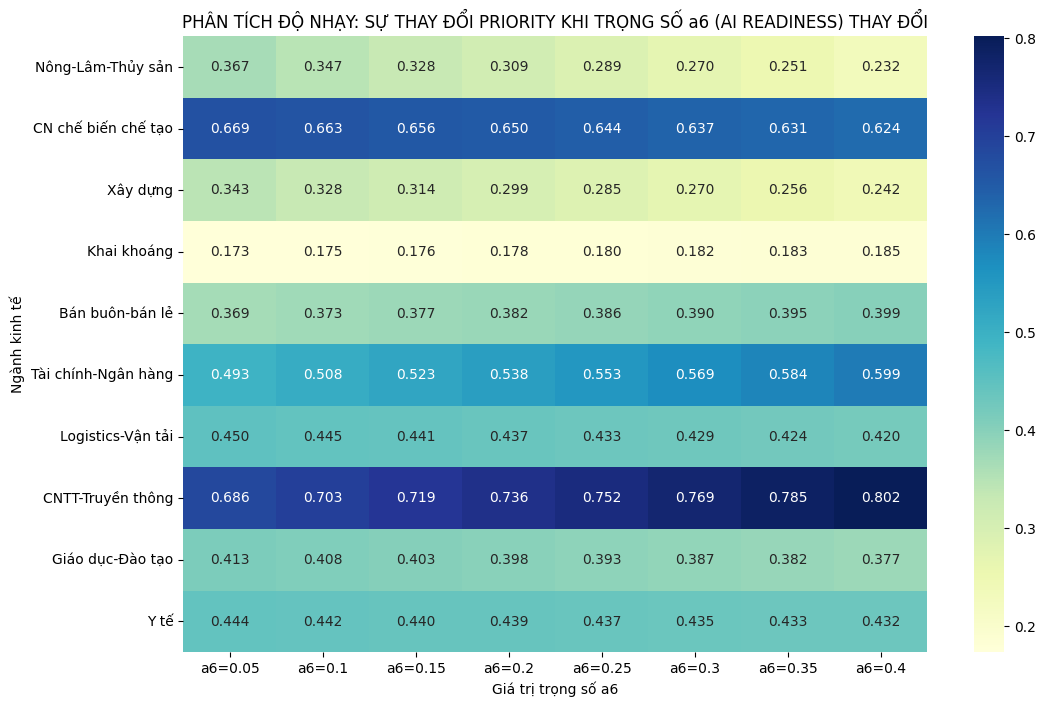

--- THEO DÕI SỰ THAY ĐỔI TOP 3 NGÀNH ---
Khi a6 = 0.05: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng
Khi a6 = 0.1: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng
Khi a6 = 0.15: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng
Khi a6 = 0.2: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng
Khi a6 = 0.25: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng
Khi a6 = 0.3: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng
Khi a6 = 0.35: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng
Khi a6 = 0.4: CNTT-Truyền thông, CN chế biến chế tạo, Tài chính-Ngân hàng


In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Thiết lập các bước thay đổi cho a6 (AI Readiness)
a6_steps = np.arange(0.05, 0.45, 0.05)  # Từ 0.05 đến 0.40 với bước 0.05

# Trọng số mặc định ban đầu [1]
# Thứ tự: Growth, Productivity, Spillover, Export, Employment, AI_Readiness (idx=5), Risk
w_default = np.array([0.15, 0.15, 0.20, 0.15, 0.10, 0.20, 0.15])
idx_a6 = 5
idx_others = [i for i in range(7) if i != idx_a6]

# 2. Thực hiện phân tích độ nhạy
results = []
top3_tracking = {}

for a6_new in a6_steps:
    # Chuẩn hóa lại tổng = 1 theo tỷ lệ
    # Tổng phần bánh còn lại cho các trọng số khác = 1 - a6_new
    w_new = np.zeros(7)
    w_new[idx_a6] = a6_new
    
    # Tính tổng các trọng số khác trong bộ mặc định để lấy tỷ lệ
    sum_others_default = w_default[idx_others].sum()
    
    for i in idx_others:
        w_new[i] = w_default[i] * (1 - a6_new) / sum_others_default
    
    # Tính chỉ số Priority cho kịch bản này
    priority_scenario = matrix_values @ w_new
    results.append(priority_scenario)
    
    # Xác định Top 3 ngành
    temp_df = pd.DataFrame({'Ngành': df_final['Ngành'], 'Score': priority_scenario})
    top3 = temp_df.sort_values('Score', ascending=False).head(3)['Ngành'].tolist()
    top3_tracking[round(a6_new, 2)] = top3

# 3. Chuẩn bị dữ liệu cho Heatmap
heatmap_data = pd.DataFrame(
    np.array(results).T, 
    index=df_final['Ngành'], 
    columns=[f"a6={round(a, 2)}" for a in a6_steps]
)

# 4. Vẽ biểu đồ Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_df := heatmap_data, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("PHÂN TÍCH ĐỘ NHẠY: SỰ THAY ĐỔI PRIORITY KHI TRỌNG SỐ a6 (AI READINESS) THAY ĐỔI")
plt.xlabel("Giá trị trọng số a6")
plt.ylabel("Ngành kinh tế")
plt.savefig('../outputs/heatmap_priority_343.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. In kết quả thay đổi Top 3
print("--- THEO DÕI SỰ THAY ĐỔI TOP 3 NGÀNH ---")
for a, top in top3_tracking.items():
    print(f"Khi a6 = {a}: {', '.join(top)}")

In [14]:
# --- BƯỚC 6: SO SÁNH HAI KỊCH BẢN CHÍNH SÁCH (CÂU 3.4.4) ---

# Định nghĩa các bộ trọng số theo yêu cầu đề bài [1, 2]
# Thứ tự trọng số: [Growth, Productivity, Spillover, Export, Employment, AI_Readiness, Risk_Inverted]

# 1. Kịch bản "Định hướng tăng trưởng": Ưu tiên tăng trưởng, năng suất, xuất khẩu
# Ta phân bổ trọng số cao (0.25) cho 3 tiêu chí này, các tiêu chí còn lại giữ mức thấp.
w_growth = np.array([0.25, 0.25, 0.05, 0.25, 0.05, 0.10, 0.05])

# 2. Kịch bản "Định hướng bao trùm": Ưu tiên việc làm, lan tỏa, giảm rủi ro
# Ta phân bổ trọng số cao cho Việc làm (0.30), Lan tỏa (0.25), Rủi ro (0.25)
w_inclusive = np.array([0.05, 0.05, 0.25, 0.05, 0.30, 0.10, 0.20])

# Tính toán điểm Priority cho cả 2 kịch bản
priority_growth = matrix_values @ w_growth
priority_inclusive = matrix_values @ w_inclusive

# Tạo DataFrame so sánh kết quả
df_comparison = pd.DataFrame({
    'Ngành': df_raw['Ngành'],
    'Priority (Tăng trưởng)': priority_growth,
    'Priority (Bao trùm)': priority_inclusive
})

# Xác định Top 3 cho từng kịch bản
top3_growth = df_comparison.sort_values('Priority (Tăng trưởng)', ascending=False).head(3)['Ngành'].tolist()
top3_inclusive = df_comparison.sort_values('Priority (Bao trùm)', ascending=False).head(3)['Ngành'].tolist()

# Hiển thị bảng so sánh
print("--- SO SÁNH CHỈ SỐ PRIORITY GIỮA HAI ĐỊNH HƯỚNG ---")
print(df_comparison.round(4).to_string(index=False))

print("\n--- KẾT QUẢ TOP 3 ---")
print(f"Top 3 Định hướng Tăng trưởng: {', '.join(top3_growth)}")
print(f"Top 3 Định hướng Bao trùm: {', '.join(top3_inclusive)}")

--- SO SÁNH CHỈ SỐ PRIORITY GIỮA HAI ĐỊNH HƯỚNG ---
              Ngành  Priority (Tăng trưởng)  Priority (Bao trùm)
  Nông-Lâm-Thủy sản                  0.2392               0.5472
CN chế biến chế tạo                  0.6770               0.6836
           Xây dựng                  0.2847               0.3641
        Khai khoáng                  0.2776               0.0720
    Bán buôn-bán lẻ                  0.3174               0.4523
Tài chính-Ngân hàng                  0.5248               0.4014
  Logistics-Vận tải                  0.4029               0.4125
  CNTT-Truyền thông                  0.6725               0.6003
   Giáo dục-Đào tạo                  0.3042               0.4326
               Y tế                  0.3681               0.4227

--- KẾT QUẢ TOP 3 ---
Top 3 Định hướng Tăng trưởng: CN chế biến chế tạo, CNTT-Truyền thông, Tài chính-Ngân hàng
Top 3 Định hướng Bao trùm: CN chế biến chế tạo, CNTT-Truyền thông, Nông-Lâm-Thủy sản
